# 📘 Análisis Multivariado y Storytelling de Recursos Humanos

🔹 Introducción

Este dataset contiene datos de empleados de una empresa. El objetivo es explorar cómo diferentes características se relacionan con la deserción laboral (Attrition) y construir un modelo analítico, visual e interpretativo que pueda servir para presentar hallazgos a un equipo de RRHH o dirección.

📊 Columnas relevantes incluyen:

- Age, Gender, MaritalStatus

- Attrition: Variable objetivo (Sí/No)

- JobSatisfaction, WorkLifeBalance, MonthlyIncome

- DistanceFromHome, BusinessTravel, YearsAtCompany

- TotalWorkingYears, NumCompaniesWorked, etc.

### 📂 Parte 1 – Análisis Exploratorio y Preparación

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.info()

# Limpieza básica
df.drop(columns=["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"], inplace=True)

# Codificar columnas categóricas para análisis multivariado
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include="object"):
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

df_encoded.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


### 📈 Parte 2 – Análisis Multivariado

1. Heatmap de Correlación

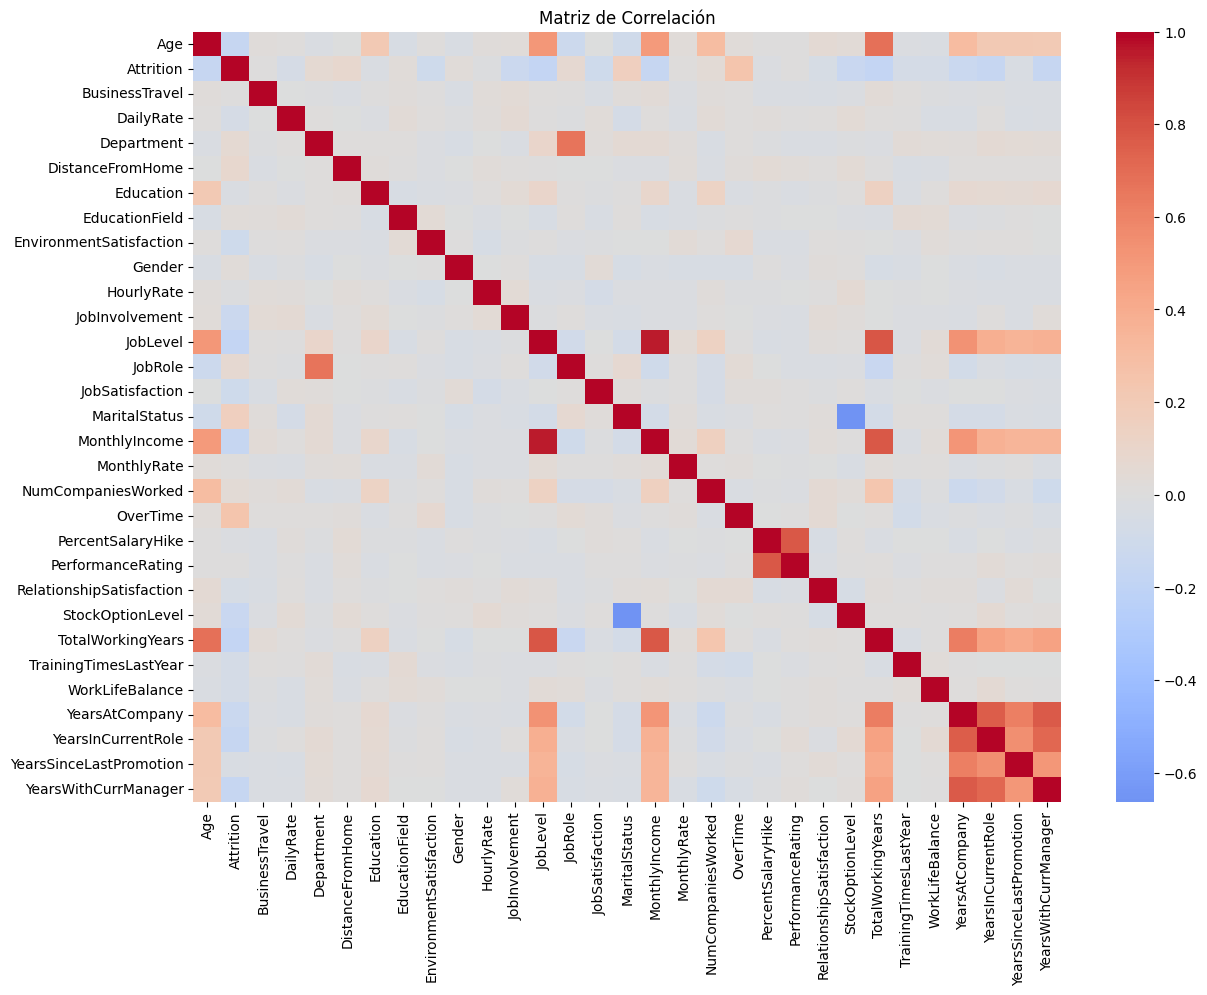

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm', center=0)
plt.title("Matriz de Correlación")
plt.show()


##### 📌 Actividad 1: ¿Qué variables parecen estar más correlacionadas con Attrition? ¿Y entre sí?

- Attrition muestra correlaciones débiles.
- Con Departament, DailyRate, JobRole, DistancesFromHome: corr. débil entre 0 y 0.2.
- Con OverTime, MaritalStatus: corr. débil entre 0.2 y 0.4.

- Correlaciones entre sí:
    * Corr. Fuertes: 
        - MonthlyIncome-JobLevel,
        - PercentSalaryHike-PerformanceRating,
        - JobLevel-TotalWorkingYears
    * Corr. Moderadas-Fuertes:
        - Age-TotalWorkingYears,
        - DailyRate-JobRole

2. Análisis de Componentes Principales (PCA)

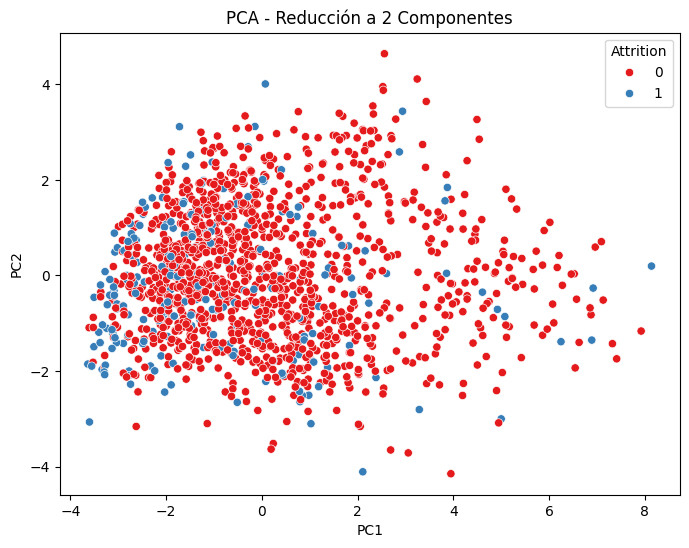

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualización
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set1')
plt.title("PCA - Reducción a 2 Componentes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


##### 📌 Actividad 2: ¿Qué tanto se separan las clases de Attrition en el espacio reducido? ¿Qué significa esto?
En el espacio reducido, no existe una separación clara entre las clases de Atrittion, por lo cual dos componentes no pueden explicar el fenómeno de diserción laboral.
Significa que las clases no son linealmente separables por lo tanto el método PCA de reducción a 2 componentesno no resulta el adecuado para analizar este caso. 

### 📊 Parte 3 – Visualizaciones Avanzadas

3. Violinplot + Boxplot

In [ ]:
plt.figure(figsize=(10,6))
sns.violinplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Distribución del Ingreso Mensual según Attrition")
plt.show()


##### 📌 Actividad 3: ¿Qué conclusiones podrías sacar sobre ingresos y deserción?
- Empleados que desertan tienen ingresos mensuales más bajos en promedio.
- El Ingreso es un factor importante pero no el único, puesto que existen empleados con salarios altos que también desertan.
* Observaciones Estadísticas:
    - Atrittion-si: curva leptocútrica, con valores más concentrados.
    - Atrittion-no: distribución mas acampanada, con valores más dispersos. Lo que refiere a una mayor variabilidad.

4. Lineplots & FacetGrid

In [ ]:
sns.lineplot(x="YearsAtCompany", y="MonthlyIncome", data=df)
plt.title("Ingreso en función de los años en la empresa")
plt.show()

# Multigráfico
g = sns.FacetGrid(df, col="Attrition", height=4)
g.map_dataframe(sns.histplot, x="TotalWorkingYears", kde=True)
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Distribución de Años de Trabajo según Attrition")
plt.show()


##### 📌 Actividad 4: ¿Qué diferencias observás entre empleados que renunciaron y los que no?
- Empleados que renuncian: 
    * distribucion acampanada, con distribución más dispersa en años bajos de experiencia, rango de 0-10.
    * cola muy larga hacia la derecha, pero con poca frecuencia.
    * rango de mayor frecuencia de abandono entre 0-5 años.
- Empleados que no renuncian:
    * distribución leptocurtica, con mayor concentración de datos en un rango aprox. entre 8 y 12 años de experiencia.
    * cola hacia la derecha, pero con poca frecuencia.
    * los empleados que superan los 8 años tienden a quedarse en la empresa.
    
Conlusiones: La empresa retiene bien a empleados con experiencia media, pero por diversos factores pierde empleados en otros niveles.. 


5. Pairplot

In [ ]:
sns.pairplot(df_encoded[['Age', 'DistanceFromHome', 'YearsAtCompany', 'MonthlyIncome', 'Attrition']], hue="Attrition")
plt.show()


##### 📌 Actividad 5: ¿Qué relaciones ocultas podés observar?

* Age:
    - Age - MonthlyIncome: Relación positiva: a mayor edad, mayor ingreso mensual. Empleados que desertan tienden a ser más jóvenes con ingresos más bajos.
    - Age - YearsAtCompany: Empleados con menor antigëdad tienden a desertar con más frecuencia.

* DistanceFromHome: 
    -  DistanceFromHome - Age: Deserción con relación directa hasta aproximadamente los 35 años. Siendo para los más jóvenes un patron inverso, puesto que en un rango de menor distacia existe una tendencia a desertar.
    - DistanceFromHome - YearsAtCompany: Empleados con menos de 10 años de antigüedad tienen a renunciar a medida que aumentan las distancias
    DistanceFromHom -MonthlyIncome: a menores ingresos y mayor distancia tiende a aumentar la deserción.
* YearsAtCompany:
    - YearsAtCompany -MonthlyIncome: Patron de diserción difuso, aunque se percibe que la deserción tiene más frecuencia con ingresos y antigüedad bajos.


### 🧪 Parte 4 – Inferencia: Pruebas de Hipótesis y Intervalos

6. Prueba de Hipótesis: ¿Ganan más los que se quedan?

In [ ]:
from scipy.stats import ttest_ind

stay = df[df['Attrition'] == 'No']['MonthlyIncome']
leave = df[df['Attrition'] == 'Yes']['MonthlyIncome']

t_stat, p_value = ttest_ind(stay, leave, equal_var=False)
print(f"T-Stat: {t_stat:.2f}, p-Valor: {p_value:.4f}")


##### 📌 Actividad 6: ¿Se puede rechazar la hipótesis nula de que ganan igual?

De acuerdo a los resultados arrojados, se rechaza la Hipótesis Nula de que ganan igual debido a que p-valor~0 < 0.05. Indicando que quienes se quedan, ganan más en promedio.

7. Intervalo de Confianza para Satisfacción Laboral

In [ ]:
from scipy import stats

mean_js = df[df["Attrition"] == "Yes"]["JobSatisfaction"].mean()
sem_js = stats.sem(df[df["Attrition"] == "Yes"]["JobSatisfaction"])
ci = stats.t.interval(0.95, len(stay)-1, loc=mean_js, scale=sem_js)

print(f"IC 95% para JobSatisfaction (Attrition = Yes): {ci}")


### 🧠 Parte 5 – Actividades Finales de Storytelling

#### 🎯 Proyecto Final

#### 📌 Objetivo: Presentar una historia clara y visualmente atractiva sobre las causas más relevantes de deserción laboral en esta empresa. Usar visualizaciones, texto y análisis para:

Consignas:

- Construir al menos 3 visualizaciones distintas, incluyendo una multivariada.

- Incluir al menos una prueba de hipótesis o intervalo de confianza.

- Identificar patrones relevantes con técnicas de reducción de dimensionalidad.

- Escribir una narrativa clara que responda:

  - ¿Por qué los empleados renuncian?

  - ¿Qué grupo está en mayor riesgo?

  - ¿Qué puede hacer la empresa?

📊 Pueden utilizar Seaborn, Plotly, Pandas o cualquier herramienta para la presentación visual. Se evaluará la claridad del análisis, la creatividad visual y la solidez de la interpretación.